In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr
import warnings
from mpl_toolkits.mplot3d import Axes3D
from plotly.subplots import make_subplots
warnings.filterwarnings('ignore', category=FutureWarning)

In [ ]:
df = pd.read_csv(os.path.join(os.path.dirname(__file__), '..', 'data', 'id3_prices.csv'), index_col=0, parse_dates=True)
df_results = pd.read_csv(os.path.join(os.path.dirname(__file__), '..', 'data', 'predictions.csv'), index_col=0, parse_dates=True)
df_pca_results = pd.read_csv(os.path.join(os.path.dirname(__file__), '..', 'data', 'pca_predictions.csv'), index_col=0, parse_dates=True)
df_arima_results = pd.read_csv(os.path.join(os.path.dirname(__file__), '..', 'data', 'arima_predictions.csv'), index_col=0, parse_dates=True)

In [ ]:
# Align data - get common indices
common_index = df.index.intersection(df_pca_results.index).intersection(df_results.index).intersection(df_arima_results.index)
df_actual = df.loc[common_index]
df_ica_pred = df_results.loc[common_index]
df_pca_pred = df_pca_results.loc[common_index]
df_arima_pred = df_arima_results.loc[common_index]

# Naive prediction (previous day's prices)
df_naive_pred = df_actual.shift(1).dropna()
common_index_naive = df_actual.index.intersection(df_naive_pred.index)
df_actual_naive = df_actual.loc[common_index_naive]
df_naive_pred = df_naive_pred.loc[common_index_naive]

In [ ]:
def calculate_price_metrics(actual, predicted, model_name):
    """Calculate price prediction metrics"""
    # Flatten arrays
    actual_flat = actual.values.flatten()
    predicted_flat = predicted.values.flatten()
    
    # Remove NaN values
    mask = ~(np.isnan(actual_flat) | np.isnan(predicted_flat))
    actual_clean = actual_flat[mask]
    predicted_clean = predicted_flat[mask]
    
    # Calculate metrics
    mae = mean_absolute_error(actual_clean, predicted_clean)
    rmse = np.sqrt(mean_squared_error(actual_clean, predicted_clean))
    
    # Relative MAE (rMAE) - MAE normalized by mean of actual values
    rmae = mae / np.mean(np.abs(actual_clean))
    
    # MAPE - Mean Absolute Percentage Error
    # Avoid division by zero by adding small epsilon
    epsilon = 1e-8
    mape = np.mean(np.abs((actual_clean - predicted_clean) / (actual_clean + epsilon))) * 100
    
    # sMAPE - Symmetric Mean Absolute Percentage Error
    smape = np.mean(2 * np.abs(actual_clean - predicted_clean) / 
                   (np.abs(actual_clean) + np.abs(predicted_clean) + epsilon)) * 100
    
    # Spearman rank correlation coefficient
    spearman_corr, _ = spearmanr(actual_clean, predicted_clean)
    
    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'rMAE': rmae,
        'MAPE': mape,
        'sMAPE': smape,
        'Spearman': spearman_corr,
        'N_Observations': len(actual_clean)
    }

# Calculate metrics for all models
metrics_list = []
metrics_list.append(calculate_price_metrics(df_actual, df_ica_pred, 'ICA'))
metrics_list.append(calculate_price_metrics(df_actual, df_pca_pred, 'PCA'))
metrics_list.append(calculate_price_metrics(df_actual, df_arima_pred, 'ARIMA'))
metrics_list.append(calculate_price_metrics(df_actual_naive, df_naive_pred, 'Naive'))

metrics_df = pd.DataFrame(metrics_list)
print("Price Prediction Metrics:")
print("=" * 60)
print(metrics_df.round(4))

Price Prediction Metrics:
   Model      MAE      RMSE    rMAE      MAPE     sMAPE  Spearman  \
0    ICA  29.3147   53.9995  0.3249  349.0693   37.7675    0.8091   
1    PCA  92.5335  135.0228  1.0256  252.6442  164.8379    0.0465   
2  ARIMA  25.5002   47.2548  0.2826  292.4914   36.6863    0.8307   
3  Naive  27.9111   53.6680  0.3093  255.3920   42.5502    0.7955   

   N_Observations  
0           67680  
1           67680  
2           67680  
3           67656  


In [ ]:
# Calculate quarterly metrics
def calculate_quarterly_price_metrics(actual_df, predicted_df, model_name):
    """Calculate price metrics for quarterly intervals"""
    quarterly_results = []
    
    # Group by quarters  
    quarters = actual_df.groupby(pd.Grouper(freq='Q'))
    
    for quarter_end, quarter_actual in quarters:
        if len(quarter_actual) == 0:
            continue
            
        quarter_predicted = predicted_df.loc[quarter_actual.index]
        
        # Skip if indices don't match
        if len(quarter_predicted) == 0:
            continue
            
        result = calculate_price_metrics(quarter_actual, quarter_predicted, model_name)
        result['Quarter'] = quarter_end
        quarterly_results.append(result)
    
    return quarterly_results

# Calculate quarterly metrics for all models
quarterly_metrics = []
quarterly_metrics.extend(calculate_quarterly_price_metrics(df_actual, df_ica_pred, 'ICA'))
quarterly_metrics.extend(calculate_quarterly_price_metrics(df_actual, df_pca_pred, 'PCA'))
quarterly_metrics.extend(calculate_quarterly_price_metrics(df_actual, df_arima_pred, 'ARIMA'))
quarterly_metrics.extend(calculate_quarterly_price_metrics(df_actual_naive, df_naive_pred, 'Naive'))

quarterly_df = pd.DataFrame(quarterly_metrics)

print("\nQuarterly Price Prediction Performance:")
print("=" * 60)
quarterly_pivot = quarterly_df.pivot_table(index='Quarter', columns='Model', 
                                         values=['MAE', 'RMSE', 'rMAE', 'MAPE', 'sMAPE', 'Spearman'])
print(quarterly_pivot.round(4))


Quarterly Price Prediction Performance:
                MAE                                    MAPE             \
Model         ARIMA       ICA    Naive       PCA      ARIMA        ICA   
Quarter                                                                  
2017-12-31  20.1580   24.8881  18.2371   21.8331  1512.9630  1788.2416   
2018-03-31  10.8889   11.0875  13.2945   39.2195   159.0881   160.8074   
2018-06-30   9.6915   10.3373  11.3350   36.5639    71.2903    76.6575   
2018-09-30   9.8641   11.1422  10.5668   54.8328   217.7608   219.1486   
2018-12-31  12.4402   12.9861  14.6499   51.9276   208.6790   218.5113   
2019-03-31  11.6867   12.0982  13.9947   41.8346   312.4463   329.8017   
2019-06-30  10.0571    9.8569  12.3009   40.7540   203.0524   211.4262   
2019-09-30   8.3519    8.2414  10.0120   39.9829    46.1097    48.0523   
2019-12-31   9.6143    9.6780  11.6222   38.4617   265.5447   314.5876   
2020-03-31  10.7345   10.5900  12.6339   29.7018   272.1031   314.1963 

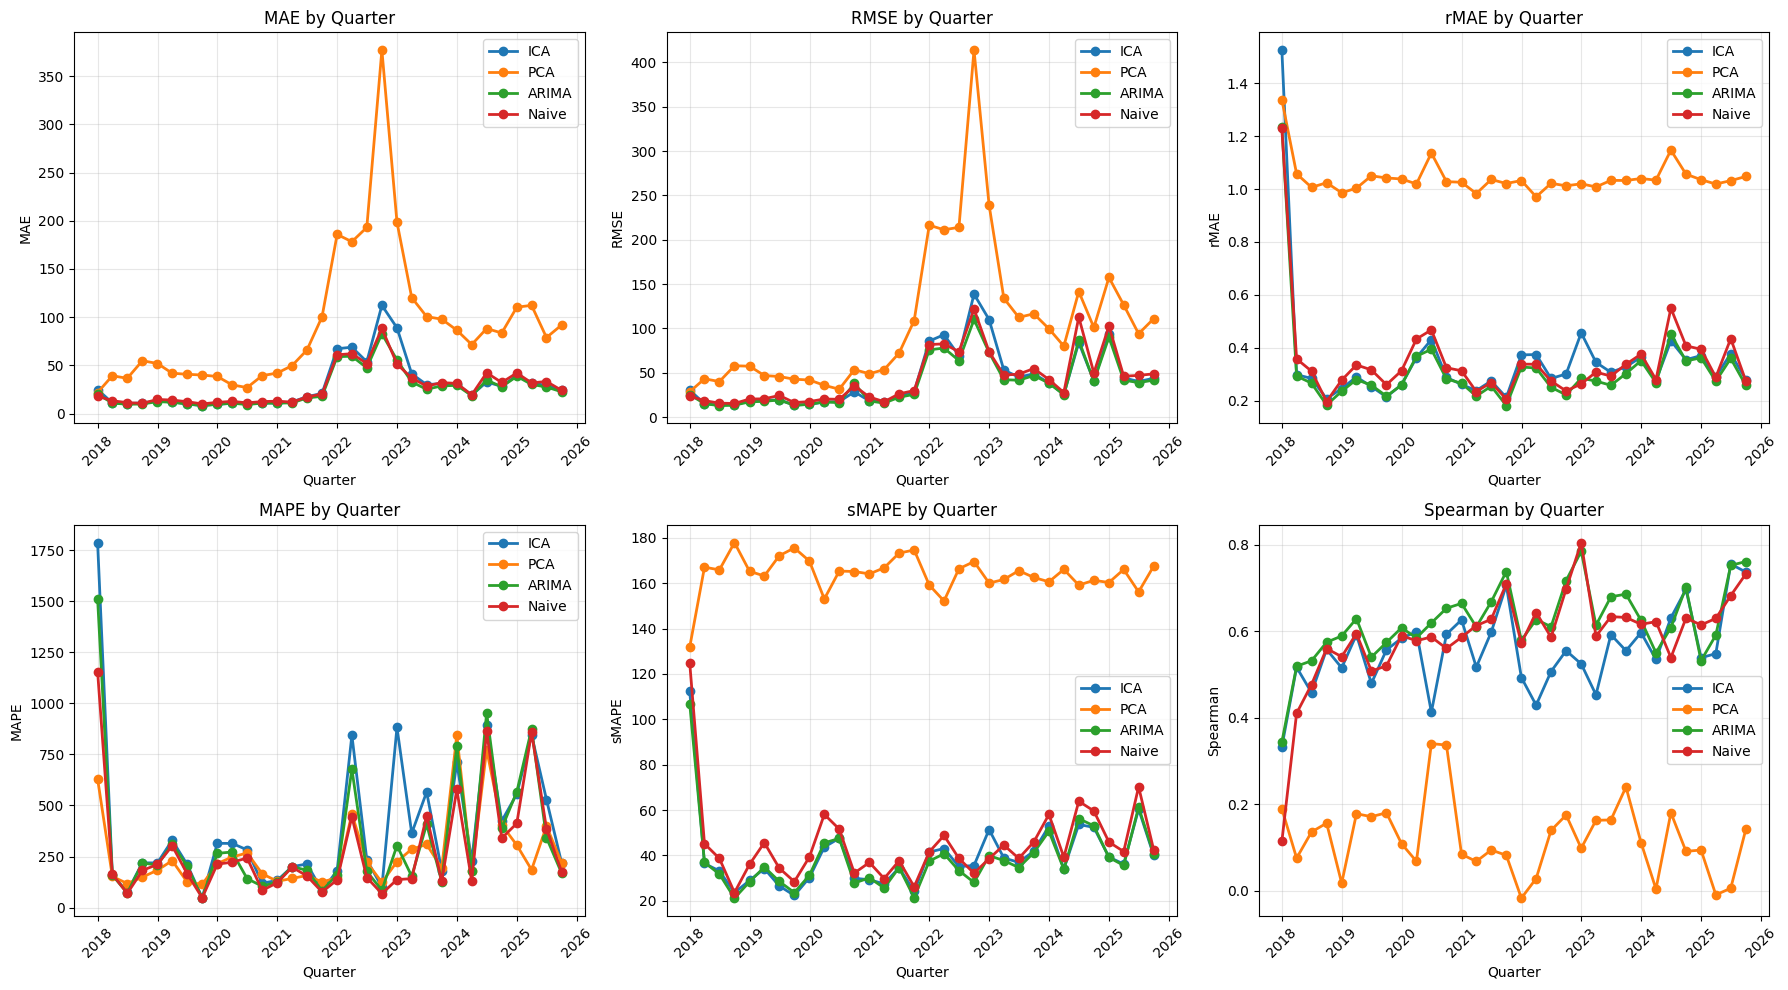

In [ ]:
# Plot quarterly progression
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics_to_plot = ['MAE', 'RMSE', 'rMAE', 'MAPE', 'sMAPE', 'Spearman']
for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    
    for model in ['ICA', 'PCA', 'ARIMA', 'Naive']:
        model_data = quarterly_df[quarterly_df['Model'] == model]
        if len(model_data) > 0:
            ax.plot(model_data['Quarter'], model_data[metric], marker='o', label=model, linewidth=2)
    
    ax.set_title(f'{metric} by Quarter')
    ax.set_xlabel('Quarter') 
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

# Hide the last subplot if not used
if len(metrics_to_plot) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

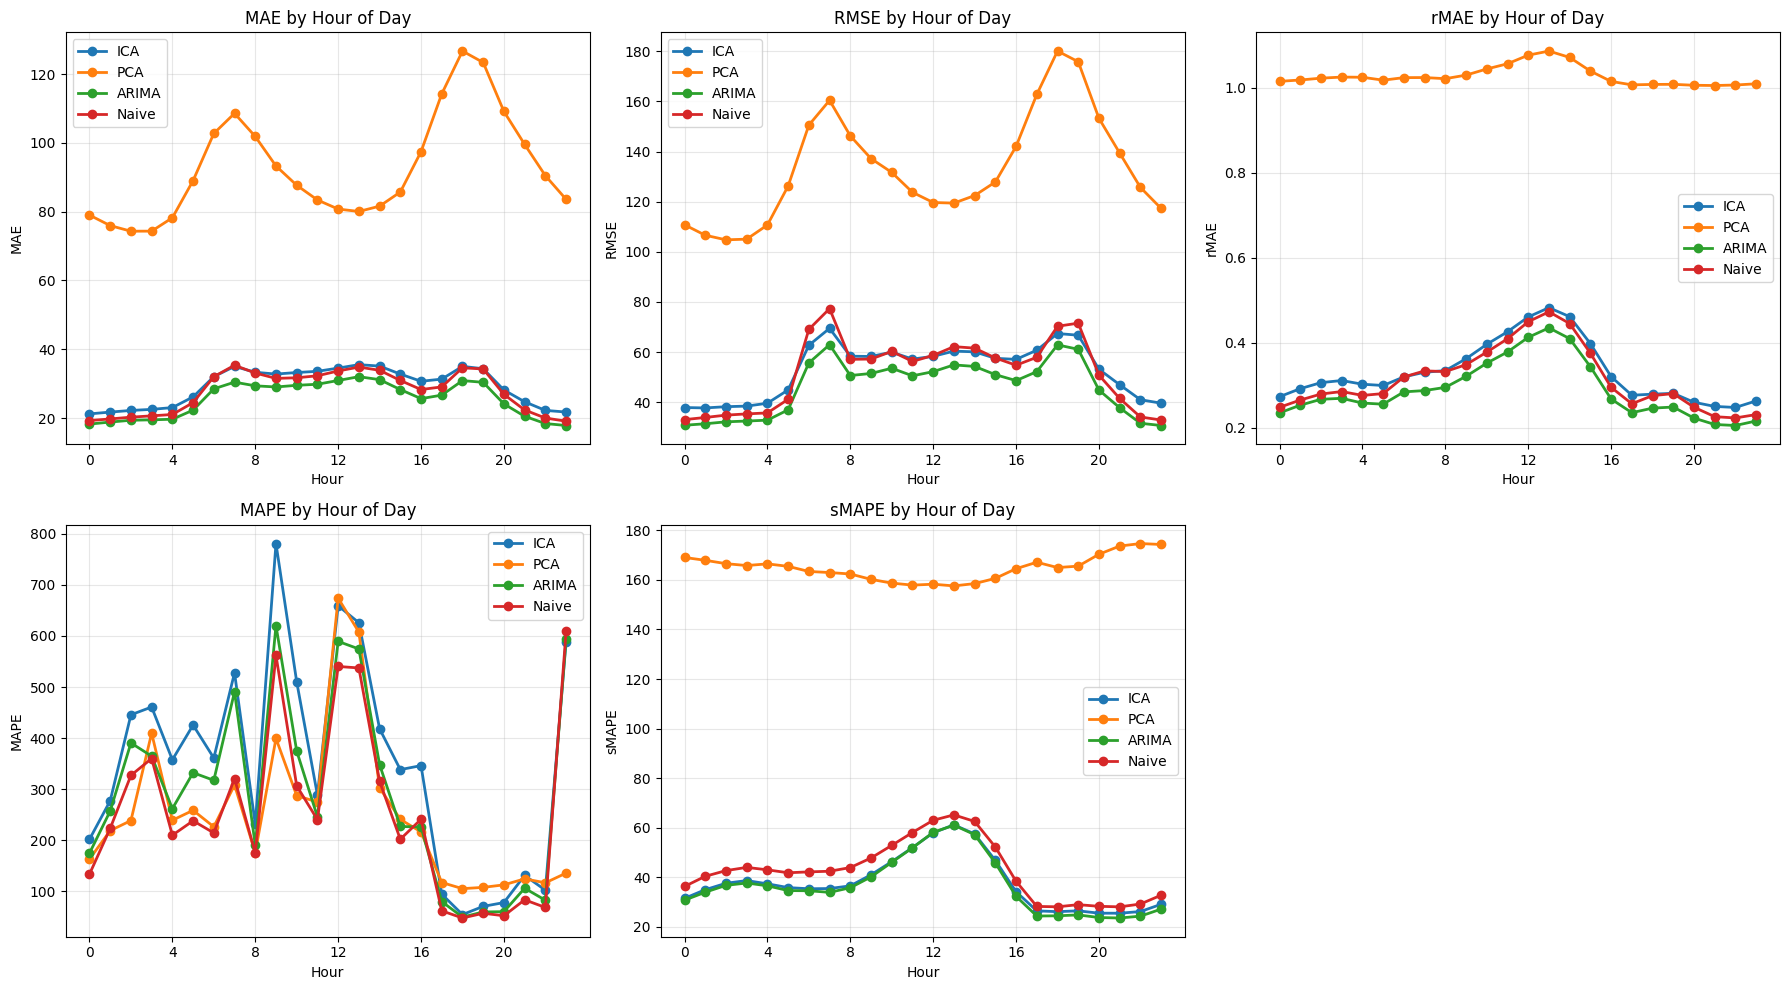

In [ ]:
# Hourly analysis
def calculate_hourly_price_metrics(actual_df, predicted_df, model_name):
    """Calculate price metrics by hour of day"""
    hourly_results = []
    
    for hour in range(24):
        actual_hour = actual_df.iloc[:, hour].dropna()
        predicted_hour = predicted_df.iloc[:, hour].reindex(actual_hour.index).dropna()
        
        # Align the data
        common_index = actual_hour.index.intersection(predicted_hour.index)
        if len(common_index) == 0:
            continue
            
        actual_hour_clean = actual_hour.loc[common_index]
        predicted_hour_clean = predicted_hour.loc[common_index]
        
        # Calculate metrics
        mae = mean_absolute_error(actual_hour_clean, predicted_hour_clean)
        rmse = np.sqrt(mean_squared_error(actual_hour_clean, predicted_hour_clean))
        rmae = mae / np.mean(np.abs(actual_hour_clean))
        
        epsilon = 1e-8
        mape = np.mean(np.abs((actual_hour_clean - predicted_hour_clean) / 
                             (actual_hour_clean + epsilon))) * 100
        smape = np.mean(2 * np.abs(actual_hour_clean - predicted_hour_clean) / 
                       (np.abs(actual_hour_clean) + np.abs(predicted_hour_clean) + epsilon)) * 100
        
        hourly_results.append({
            'Hour': hour,
            'Model': model_name,
            'MAE': mae,
            'RMSE': rmse,
            'rMAE': rmae,
            'MAPE': mape,
            'sMAPE': smape,
            'Spearman': spearmanr(actual_hour_clean, predicted_hour_clean)[0]
        })
    
    return hourly_results

# Calculate hourly metrics
hourly_metrics = []
hourly_metrics.extend(calculate_hourly_price_metrics(df_actual, df_ica_pred, 'ICA'))
hourly_metrics.extend(calculate_hourly_price_metrics(df_actual, df_pca_pred, 'PCA'))
hourly_metrics.extend(calculate_hourly_price_metrics(df_actual, df_arima_pred, 'ARIMA'))
hourly_metrics.extend(calculate_hourly_price_metrics(df_actual_naive, df_naive_pred, 'Naive'))

hourly_df = pd.DataFrame(hourly_metrics)

# Plot hourly metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(['MAE', 'RMSE', 'rMAE', 'MAPE', 'sMAPE', 'Spearman']):
    ax = axes[i]
    
    for model in ['ICA', 'PCA', 'ARIMA', 'Naive']:
        model_data = hourly_df[hourly_df['Model'] == model]
        ax.plot(model_data['Hour'], model_data[metric], marker='o', label=model, linewidth=2)
    
    ax.set_title(f'{metric} by Hour of Day')
    ax.set_xlabel('Hour')
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(0, 24, 4))

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

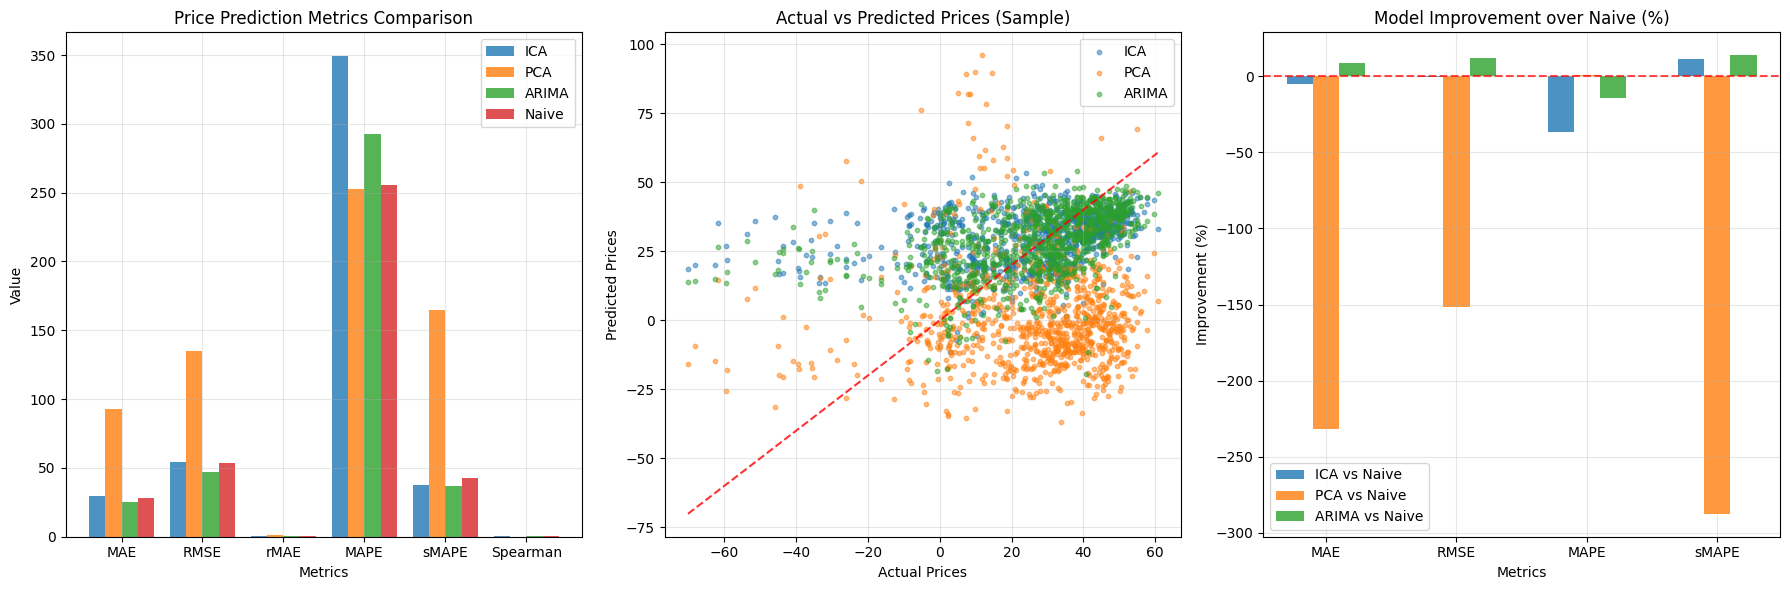

In [ ]:
# Summary comparison plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Bar chart comparison
metrics_names = ['MAE', 'RMSE', 'rMAE', 'MAPE', 'sMAPE', 'Spearman']
ica_values = [metrics_df[metrics_df['Model'] == 'ICA'][metric].iloc[0] for metric in metrics_names]
pca_values = [metrics_df[metrics_df['Model'] == 'PCA'][metric].iloc[0] for metric in metrics_names]
arima_values = [metrics_df[metrics_df['Model'] == 'ARIMA'][metric].iloc[0] for metric in metrics_names]
naive_values = [metrics_df[metrics_df['Model'] == 'Naive'][metric].iloc[0] for metric in metrics_names]

x = np.arange(len(metrics_names))
width = 0.2

axes[0].bar(x - width*1.5, ica_values, width, label='ICA', alpha=0.8)
axes[0].bar(x - width/2, pca_values, width, label='PCA', alpha=0.8)
axes[0].bar(x + width/2, arima_values, width, label='ARIMA', alpha=0.8)
axes[0].bar(x + width*1.5, naive_values, width, label='Naive', alpha=0.8)
axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Value')
axes[0].set_title('Price Prediction Metrics Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scatter plot: Actual vs Predicted prices (sample)
sample_size = min(1000, len(df_actual.values.flatten()))
actual_sample = df_actual.values.flatten()[:sample_size]
ica_sample = df_ica_pred.values.flatten()[:sample_size]
pca_sample = df_pca_pred.values.flatten()[:sample_size]
arima_sample = df_arima_pred.values.flatten()[:sample_size]

axes[1].scatter(actual_sample, ica_sample, alpha=0.5, s=10, label='ICA')
axes[1].scatter(actual_sample, pca_sample, alpha=0.5, s=10, label='PCA')
axes[1].scatter(actual_sample, arima_sample, alpha=0.5, s=10, label='ARIMA')
min_val, max_val = min(actual_sample), max(actual_sample)
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
axes[1].set_xlabel('Actual Prices')
axes[1].set_ylabel('Predicted Prices')
axes[1].set_title('Actual vs Predicted Prices (Sample)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Performance improvement over naive
improvement_metrics = ['MAE', 'RMSE', 'MAPE', 'sMAPE']
ica_improvements = []
pca_improvements = []
arima_improvements = []

for metric in improvement_metrics:
    naive_val = metrics_df[metrics_df['Model'] == 'Naive'][metric].iloc[0]
    ica_val = metrics_df[metrics_df['Model'] == 'ICA'][metric].iloc[0]
    pca_val = metrics_df[metrics_df['Model'] == 'PCA'][metric].iloc[0]
    arima_val = metrics_df[metrics_df['Model'] == 'ARIMA'][metric].iloc[0]
    
    # For these metrics, lower is better, so improvement = (naive - model) / naive * 100
    ica_improvements.append((naive_val - ica_val) / naive_val * 100)
    pca_improvements.append((naive_val - pca_val) / naive_val * 100)
    arima_improvements.append((naive_val - arima_val) / naive_val * 100)

x_imp = np.arange(len(improvement_metrics))
axes[2].bar(x_imp - width, ica_improvements, width, label='ICA vs Naive', alpha=0.8)
axes[2].bar(x_imp, pca_improvements, width, label='PCA vs Naive', alpha=0.8)
axes[2].bar(x_imp + width, arima_improvements, width, label='ARIMA vs Naive', alpha=0.8)
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[2].set_xlabel('Metrics')
axes[2].set_ylabel('Improvement (%)')
axes[2].set_title('Model Improvement over Naive (%)')
axes[2].set_xticks(x_imp)
axes[2].set_xticklabels(improvement_metrics)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()